# E-Commerce Advanced Business Cases (mit Visualisierung)

In diesem Notebook implementieren wir vier hochgradig praxisrelevante Data-Science & Business-Konzepte auf unserem Datensatz und visualisieren die Ergebnisse im modernen Design.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# --- 🎨 MODERNES STYLING SETUP ---
C_DARKBLUE = '#20344f'
C_BLUEGREY = '#52627b'
C_LIGHTGREY = '#edeef0'
C_LEMON = '#e0ff01'

mpl.rcParams['figure.facecolor'] = C_DARKBLUE
mpl.rcParams['axes.facecolor'] = C_DARKBLUE
mpl.rcParams['axes.edgecolor'] = C_BLUEGREY
mpl.rcParams['axes.labelcolor'] = C_LIGHTGREY
mpl.rcParams['xtick.color'] = C_LIGHTGREY
mpl.rcParams['ytick.color'] = C_LIGHTGREY
mpl.rcParams['text.color'] = C_LIGHTGREY
mpl.rcParams['grid.color'] = C_BLUEGREY
# ---------------------------------

def lade_daten():
    return pd.read_csv("online_shoppers_intention.csv")

print("Bibliotheken und Styling geladen!")

Bibliotheken und Styling geladen!


## 1. Smart Vouchers (`predict_proba`)
Wir verteilen Gutscheine nicht blind an alle, sondern **nur an Kunden, deren Kaufwahrscheinlichkeit zwischen 40% und 60% liegt** (die Unentschlossenen).

Von 2466 Test-Besuchern sind genau 98 'auf der Kippe'.


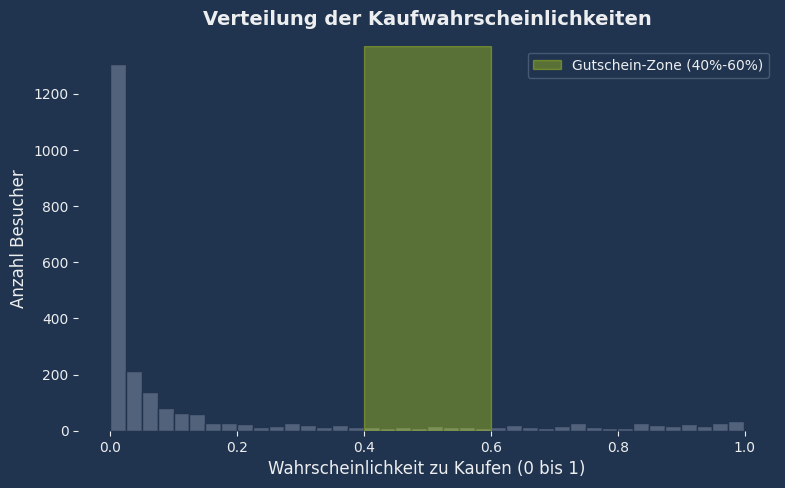

In [2]:
df = lade_daten()
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=['Revenue'])
y = df_encoded['Revenue'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(16, 8), random_state=42, max_iter=300)
mlp.fit(X_train_scaled, y_train)

# WAHRSCHEINLICHKEITEN ABRUFEN
kauf_wahrscheinlichkeiten = mlp.predict_proba(X_test_scaled)[:, 1]

# Unentschlossene herausfiltern (40% - 60%)
unentschlossen_mask = (kauf_wahrscheinlichkeiten >= 0.40) & (kauf_wahrscheinlichkeiten <= 0.60)
kunden_fuer_gutschein = X_test[unentschlossen_mask]

print(f"Von {len(X_test)} Test-Besuchern sind genau {len(kunden_fuer_gutschein)} 'auf der Kippe'.")

# -- VISUALISIERUNG --
plt.figure(figsize=(9, 5))
plt.hist(kauf_wahrscheinlichkeiten, bins=40, color=C_BLUEGREY, edgecolor=C_DARKBLUE)
plt.axvspan(0.4, 0.6, color=C_LEMON, alpha=0.3, label='Gutschein-Zone (40%-60%)')
plt.title("Verteilung der Kaufwahrscheinlichkeiten", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Wahrscheinlichkeit zu Kaufen (0 bis 1)", fontsize=12)
plt.ylabel("Anzahl Besucher", fontsize=12)
plt.legend(facecolor=C_DARKBLUE, edgecolor=C_BLUEGREY, labelcolor=C_LIGHTGREY)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.show()

## 2. Feature Selection (Ballast abwerfen)
Muss die KI wirklich über 60 Spalten durchkauen? Wir testen, ob ein Modell mit nur den **Top 3 Features** genauso gut ist.

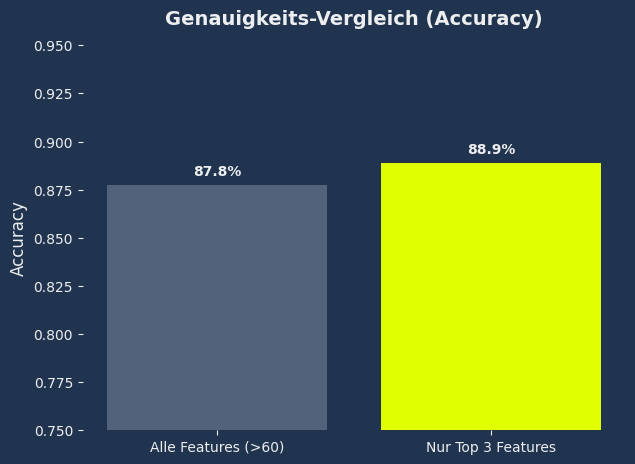

In [3]:
# Nur die Top 3 Spalten nutzen
top_features = ['PageValues', 'ExitRates', 'ProductRelated_Duration']
X_top = df[top_features]

X_train_top, X_test_top, _, _ = train_test_split(X_top, y, test_size=0.2, random_state=42)
scaler_top = StandardScaler()
X_train_top_scaled = scaler_top.fit_transform(X_train_top)
X_test_top_scaled = scaler_top.transform(X_test_top)

mlp_top = MLPClassifier(hidden_layer_sizes=(16, 8), random_state=42, max_iter=300)
mlp_top.fit(X_train_top_scaled, y_train)

acc_full = accuracy_score(y_test, mlp.predict(X_test_scaled))
acc_top = accuracy_score(y_test, mlp_top.predict(X_test_top_scaled))

# -- VISUALISIERUNG --
plt.figure(figsize=(7, 5))
bars = plt.bar(['Alle Features (>60)', 'Nur Top 3 Features'], [acc_full, acc_top], color=[C_BLUEGREY, C_LEMON])
plt.ylim(0.75, 0.95) # Zoom, um den Unterschied (oder das Fehlen davon) zu sehen
plt.title("Genauigkeits-Vergleich (Accuracy)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Accuracy", fontsize=12)

# Werte auf die Balken schreiben
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval*100:.1f}%", ha='center', color=C_LIGHTGREY, fontweight='bold')

for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.show()

## 3. Saisonale Modelle (Trainingsdaten aufteilen)
Das Kundenverhalten am Black Friday (November) ist komplett anders. Lohnt sich ein Split?

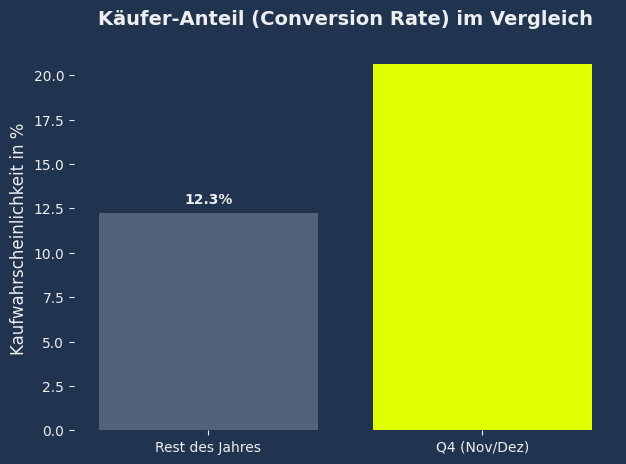

In [4]:
df = lade_daten()

df_q4 = df[df['Month'].isin(['Nov', 'Dec'])]
df_rest = df[~df['Month'].isin(['Nov', 'Dec'])]

# Conversion Rate berechnen (Käuferanteil)
cr_q4 = df_q4['Revenue'].mean() * 100
cr_rest = df_rest['Revenue'].mean() * 100

# -- VISUALISIERUNG --
plt.figure(figsize=(7, 5))
bars = plt.bar(['Rest des Jahres', 'Q4 (Nov/Dez)'], [cr_rest, cr_q4], color=[C_BLUEGREY, C_LEMON])
plt.title("Käufer-Anteil (Conversion Rate) im Vergleich", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Kaufwahrscheinlichkeit in %", fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center', color=C_DARKBLUE if yval > 15 else C_LIGHTGREY, fontweight='bold')

for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.show()

## 4. Anomalie-Erkennung (Bot-Detection)
Mit einem `IsolationForest` suchen wir die 1% ungewöhnlichsten Besucher heraus, um Scraper-Bots zu finden.

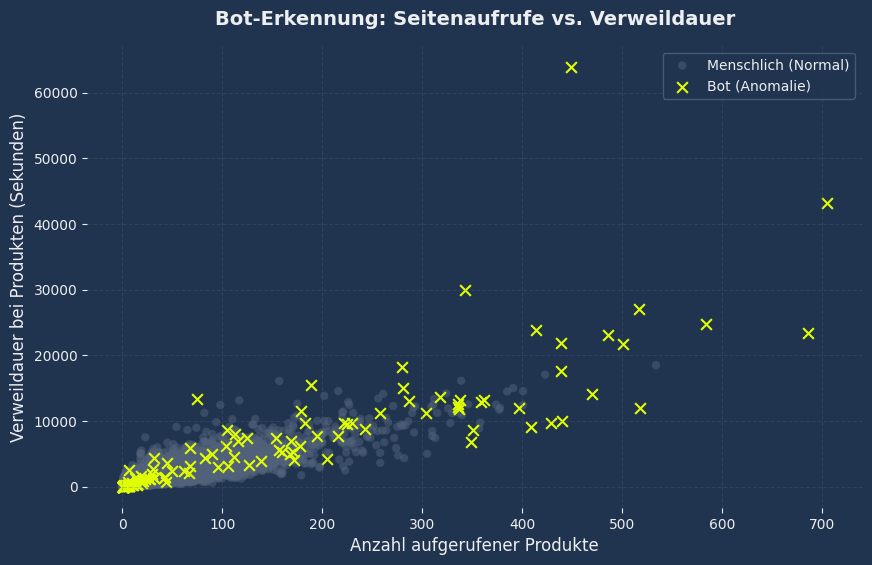

In [5]:
df = lade_daten()
numerische_spalten = df.select_dtypes(include=[np.number])

# Isolation Forest trainieren
iso_forest = IsolationForest(contamination=0.01, random_state=42)
anomalien = iso_forest.fit_predict(numerische_spalten)

# -- VISUALISIERUNG --
plt.figure(figsize=(10, 6))

# Normale Besucher plotten (Klasse 1)
normal = df[anomalien == 1]
plt.scatter(normal['ProductRelated'], normal['ProductRelated_Duration'], color=C_BLUEGREY, alpha=0.5, label='Menschlich (Normal)', edgecolors='none')

# Bots plotten (Klasse -1)
bots = df[anomalien == -1]
plt.scatter(bots['ProductRelated'], bots['ProductRelated_Duration'], color=C_LEMON, marker='x', s=60, label='Bot (Anomalie)')

plt.title("Bot-Erkennung: Seitenaufrufe vs. Verweildauer", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Anzahl aufgerufener Produkte", fontsize=12)
plt.ylabel("Verweildauer bei Produkten (Sekunden)", fontsize=12)
plt.legend(facecolor=C_DARKBLUE, edgecolor=C_BLUEGREY, labelcolor=C_LIGHTGREY)
plt.grid(True, linestyle='--', alpha=0.3)

for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.show()